# Quantitative Finance II — American Options, Credit & Portfolio Construction

| § | Topic | Models |
|---|---|---|
| A | Early exercise | CRR binomial tree, Longstaff–Schwartz least-squares Monte Carlo |
| B | Credit risk | Merton structural model, KMV distance-to-default, CDS & hazard-rate bootstrap |
| C | Portfolio construction | Markowitz, Ledoit–Wolf shrinkage, Black–Litterman, risk parity, walk-forward backtest |

Model code: `quant_ext2.py` (plus `quant_model.py` for Black–Scholes). Live inputs come from Yahoo Finance, with synthetic fallbacks when offline.

In [1]:
# ── Environment check: run this first ──
import sys, os, importlib.util
need = ["numpy", "scipy", "pandas", "matplotlib", "yfinance"]
missing = [m for m in need if importlib.util.find_spec(m) is None]
if missing:
    raise ImportError(f"Missing packages {missing}. Run in a cell:  %pip install {' '.join(missing)}")
if importlib.util.find_spec("quant_model") is None:
    raise ImportError("quant_model.py not found: open this notebook from the Quant_Portfolio folder "
                      f"(current folder: {os.getcwd()})")
print(f"OK: Python {sys.version.split()[0]} at {sys.executable}\n    working folder {os.getcwd()}")

OK: Python 3.14.5 at C:\Users\caspe\AppData\Local\Python\pythoncore-3.14-64\python.exe
    working folder C:\Users\caspe\OneDrive\Skrivebord\Quant_Portfolio


In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm

import quant_ext2 as q2
from quant_ext2 import (crr_american, lsm_american, gbm_paths, merton_structural, merton_spread_curve,
                        HazardCurve, cds_legs, bootstrap_hazard, load_equity_for_merton,
                        SECTORS, MKT_W, load_returns, ledoit_wolf, efficient_frontier, max_sharpe,
                        min_variance, risk_parity, risk_contrib, black_litterman, walk_forward)
from quant_model import bs_price

plt.rcParams.update({"figure.figsize": (11, 4.2), "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10, "axes.titleweight": "bold"})
C = plt.rcParams["axes.prop_cycle"].by_key()["color"]
q2.RNG = np.random.default_rng(5)
S, K, T, r, q, sig = 100.0, 100.0, 1.0, 0.05, 0.0, 0.20

## A · American options

An American option is an **optimal stopping** problem:

$$
V_0 = \sup_{\tau\in\mathcal T_{[0,T]}} \mathbb{E}^{\mathbb Q}\!\left[e^{-r\tau}\,h(S_\tau)\right],\qquad h(S)=(K-S)^+ .
$$

Equivalently, $V$ solves the **linear complementarity problem**

$$
\min\!\Big(-\partial_t V - \tfrac12\sigma^2S^2\partial_{SS}V - (r-q)S\,\partial_SV + rV,\;\; V-h\Big)=0,
$$

which splits the $(t,S)$ plane into a *continuation* region and an *exercise* region separated by the free boundary $S^*(t)$.

### A.1 CRR binomial tree

$u=e^{\sigma\sqrt{\Delta t}},\ d=1/u,\ p=\frac{e^{(r-q)\Delta t}-d}{u-d}$, and backward induction with the exercise check

$$
V_{i,j} = \max\!\Big(h(S_{i,j}),\; e^{-r\Delta t}\big[p\,V_{i+1,j}+(1-p)\,V_{i+1,j+1}\big]\Big).
$$

### A.2 Longstaff–Schwartz (2001)

Trees don't scale to many factors. LSM estimates the **continuation value** by regressing discounted future cash flows on basis functions of the state, using in-the-money paths only:

$$
C(t_k, S) = \mathbb{E}\!\left[e^{-r\Delta t}V_{t_{k+1}}\,\middle|\,S_{t_k}=S\right] \approx \sum_{j=0}^{M}\beta_{k,j}\,\psi_j(S),
\qquad \psi_j(x)=e^{-x/2}L_j(x),\ x=S/K,
$$

then exercises when $h(S_{t_k}) > \hat C(t_k,S_{t_k})$. The in-sample estimate is biased **high** (foresight); applying the frozen rule to **fresh paths** gives a **low-biased** estimate (a sub-optimal stopping rule can't beat the optimum).

European put (BS)     5.5735
American put (CRR)    6.0900   early-exercise premium 0.5165
LSM in-sample         6.0781 ± 0.0438   (high-biased)
LSM out-of-sample     6.0724 ± 0.0439   (low-biased)


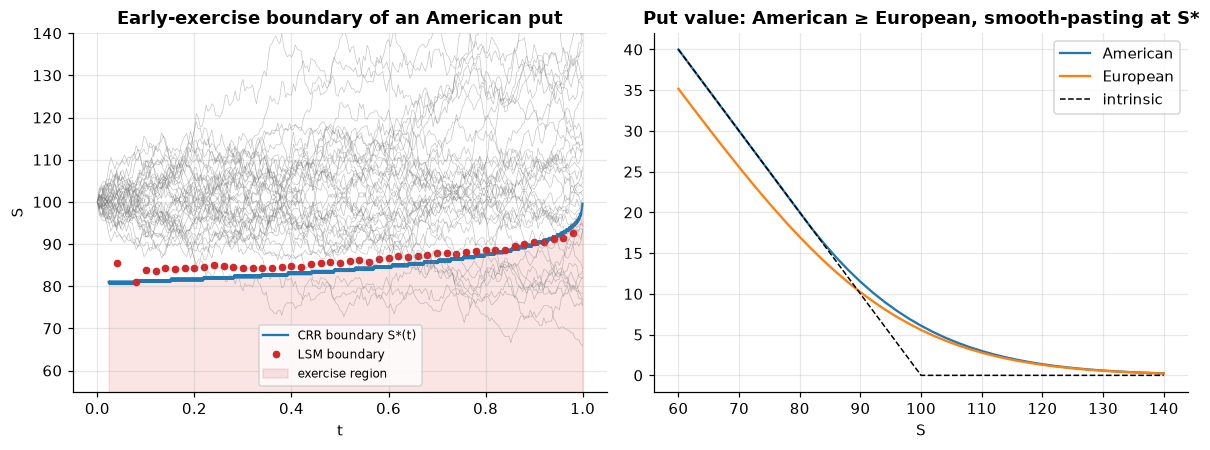

In [3]:
crr, tb, bnd = crr_american(S, K, T, r, q, sig, n=2000, cp=-1, return_boundary=True)
euro = bs_price(S, K, T, r, q, sig, -1)
res = lsm_american(S, K, T, r, q, sig, n_paths=100_000, n_steps=50, cp=-1)
print(f"European put (BS)     {euro:.4f}")
print(f"American put (CRR)    {crr:.4f}   early-exercise premium {crr-euro:.4f}")
print(f"LSM in-sample         {res['in_sample']:.4f} ± {1.96*res['in_se']:.4f}   (high-biased)")
print(f"LSM out-of-sample     {res['price']:.4f} ± {1.96*res['se']:.4f}   (low-biased)")

fig, ax = plt.subplots(1, 2)
ax[0].plot(tb, bnd, color=C[0], label="CRR boundary S*(t)")
ax[0].plot(res["t"], res["boundary"], "o", ms=4, color=C[3], label="LSM boundary")
P = gbm_paths(S, T, r, q, sig, 40, 250)
for p_ in P: ax[0].plot(np.linspace(0, T, 251), p_, color="grey", lw=0.4, alpha=0.5)
ax[0].fill_between(tb, 0, bnd, color=C[3], alpha=0.12, label="exercise region")
ax[0].set(ylim=(55, 140), title="Early-exercise boundary of an American put", xlabel="t", ylabel="S"); ax[0].legend(fontsize=8)

Ss = np.linspace(60, 140, 41)
am = [crr_american(s, K, T, r, q, sig, n=400) for s in Ss]
ax[1].plot(Ss, am, label="American"); ax[1].plot(Ss, bs_price(Ss, K, T, r, q, sig, -1), label="European")
ax[1].plot(Ss, np.maximum(K - Ss, 0), "k--", lw=1, label="intrinsic")
ax[1].set(title="Put value: American ≥ European, smooth-pasting at S*", xlabel="S"); ax[1].legend()
plt.tight_layout()

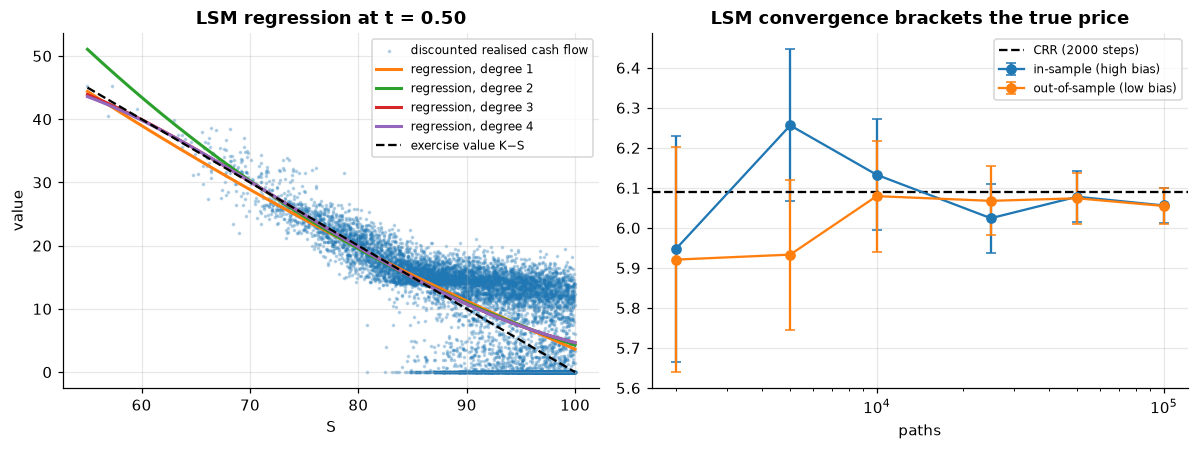

In [4]:
# The regression at one exercise date: what LSM actually "sees"
q2.RNG = np.random.default_rng(1)
k_snap = 25
dt = T/50
P = gbm_paths(S, T, r, q, sig, 20_000, 50)
CF = np.maximum(K - P[:, -1], 0)
for t in range(49, k_snap, -1):  # roll back to k_snap with a quick LSM pass
    CF *= np.exp(-r*dt); ex = np.maximum(K - P[:, t], 0); itm = ex > 0
    b, *_ = np.linalg.lstsq(q2._laguerre(P[itm, t]/K), CF[itm], rcond=None)
    idx = np.where(itm)[0][ex[itm] > q2._laguerre(P[itm, t]/K) @ b]; CF[idx] = ex[idx]
CF *= np.exp(-r*dt); ex = np.maximum(K - P[:, k_snap], 0); itm = ex > 0
xs = P[itm, k_snap]
fig, ax = plt.subplots(1, 2)
ax[0].scatter(xs, CF[itm], s=2, alpha=0.25, label="discounted realised cash flow")
grid = np.linspace(xs.min(), xs.max(), 200)
for i, deg in enumerate([1, 2, 3, 4]):
    b, *_ = np.linalg.lstsq(q2._laguerre(xs/K, deg), CF[itm], rcond=None)
    ax[0].plot(grid, q2._laguerre(grid/K, deg) @ b, color=C[i+1], lw=2, label=f"regression, degree {deg}")
ax[0].plot(grid, K - grid, "k--", label="exercise value K−S")
ax[0].set(title=f"LSM regression at t = {k_snap*dt:.2f}", xlabel="S", ylabel="value"); ax[0].legend(fontsize=8)

Ns = [2_000, 5_000, 10_000, 25_000, 50_000, 100_000]
ins, oos = [], []
for n in Ns:
    rr = lsm_american(S, K, T, r, q, sig, n_paths=n, n_steps=50); ins.append((rr["in_sample"], rr["in_se"])); oos.append((rr["price"], rr["se"]))
ins, oos = np.array(ins), np.array(oos)
for i, (lab, a) in enumerate([("in-sample (high bias)", ins), ("out-of-sample (low bias)", oos)]):
    ax[1].errorbar(Ns, a[:, 0], yerr=1.96*a[:, 1], marker="o", capsize=3, color=C[i], label=lab)
ax[1].axhline(crr, color="k", ls="--", label="CRR (2000 steps)"); ax[1].set_xscale("log")
ax[1].set(title="LSM convergence brackets the true price", xlabel="paths"); ax[1].legend(fontsize=8)
plt.tight_layout()

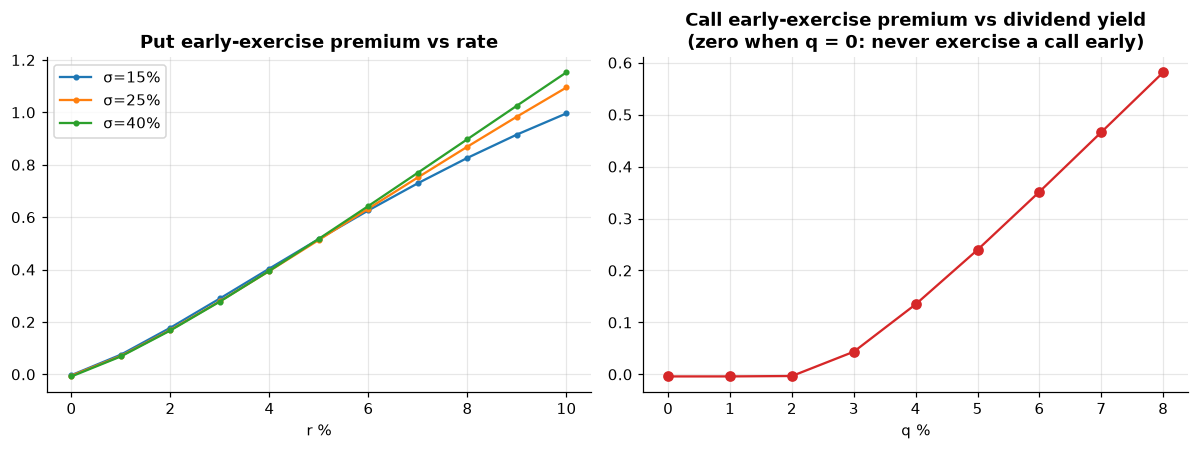

In [5]:
# Early-exercise premium across rates and dividends
fig, ax = plt.subplots(1, 2)
rs = np.linspace(0.0, 0.10, 11)
for i, sg in enumerate([0.15, 0.25, 0.40]):
    ax[0].plot(100*rs, [crr_american(S, K, T, rr, 0, sg, 500) - bs_price(S, K, T, rr, 0, sg, -1) for rr in rs], "o-", ms=3, color=C[i], label=f"σ={sg:.0%}")
ax[0].set(title="Put early-exercise premium vs rate", xlabel="r %"); ax[0].legend()
qs = np.linspace(0.0, 0.08, 9)
ax[1].plot(100*qs, [crr_american(S, K, T, 0.03, qq, 0.2, 500, cp=1) - bs_price(S, K, T, 0.03, qq, 0.2, 1) for qq in qs], "o-", color=C[3])
ax[1].set(title="Call early-exercise premium vs dividend yield\n(zero when q = 0: never exercise a call early)", xlabel="q %")
plt.tight_layout()

## B · Credit risk

### B.1 Merton structural model (1974)

Firm assets follow GBM, $dV_t = rV_t\,dt + \sigma_V V_t\,dW_t$. Debt is a zero-coupon bond with face $D$ at $T$. Equity holders own a **call on the assets**:

$$
E = V\,N(d_1) - De^{-rT}N(d_2),\qquad d_{1,2}=\frac{\ln(V/D)+(r\pm\frac12\sigma_V^2)T}{\sigma_V\sqrt T}
$$

$V$ and $\sigma_V$ aren't observed; we back them out from equity value and equity vol, using Itô on $E(V)$:

$$
\sigma_E\,E = N(d_1)\,\sigma_V\,V .
$$

Then:

$$
\text{Distance to default } DD = d_2,\qquad \text{PD}^{\mathbb Q}=N(-d_2),\qquad
s(T) = -\frac1T\ln\!\left(\frac{V N(-d_1)}{De^{-rT}} + N(d_2)\right).
$$

**KMV** convention for the default point: $D=\text{short-term debt}+\tfrac12\,\text{long-term debt}$.

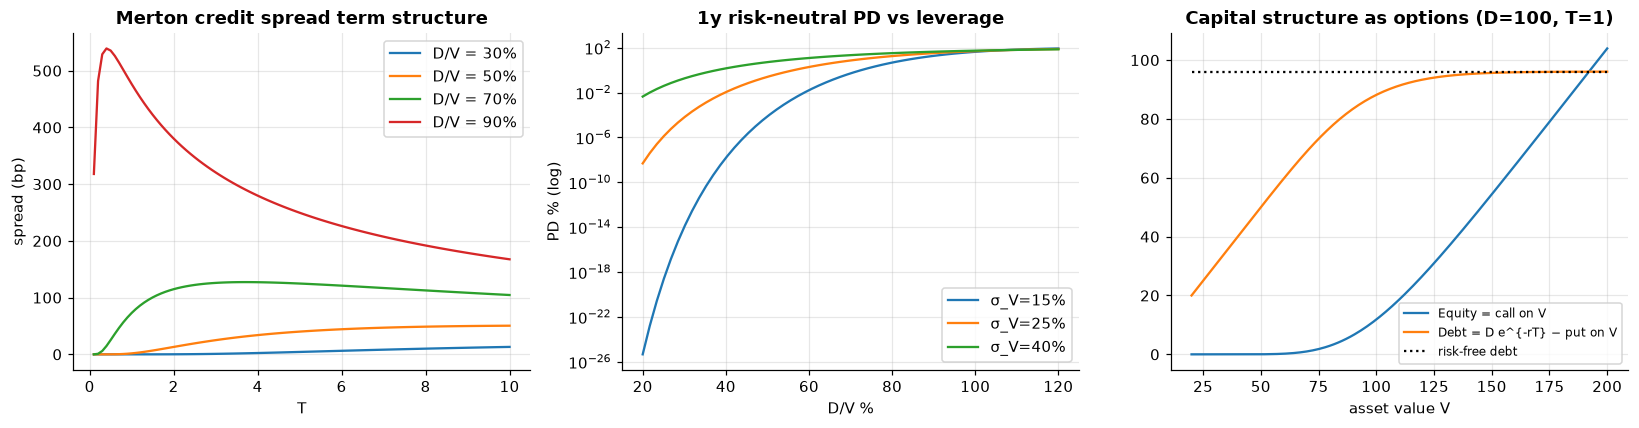

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
Ts = np.linspace(0.1, 10, 100)
for i, lev in enumerate([0.3, 0.5, 0.7, 0.9]):
    ax[0].plot(Ts, 1e4*merton_spread_curve(100, 0.25, 100*lev, 0.04, Ts), color=C[i], label=f"D/V = {lev:.0%}")
ax[0].set(title="Merton credit spread term structure", xlabel="T", ylabel="spread (bp)"); ax[0].legend()

levs = np.linspace(0.2, 1.2, 60)
for i, sv in enumerate([0.15, 0.25, 0.40]):
    d2 = (np.log(1/levs) + (0.04 - 0.5*sv**2)) / sv
    ax[1].semilogy(100*levs, 100*norm.cdf(-d2), color=C[i], label=f"σ_V={sv:.0%}")
ax[1].set(title="1y risk-neutral PD vs leverage", xlabel="D/V %", ylabel="PD % (log)"); ax[1].legend()

Vg = np.linspace(20, 200, 200)
Eq = bs_price(Vg, 100, 1, 0.04, 0, 0.25); Dv = Vg - Eq
ax[2].plot(Vg, Eq, label="Equity = call on V"); ax[2].plot(Vg, Dv, label="Debt = D e^{-rT} − put on V")
ax[2].plot(Vg, 100*np.exp(-0.04)*np.ones_like(Vg), "k:", label="risk-free debt")
ax[2].set(title="Capital structure as options (D=100, T=1)", xlabel="asset value V"); ax[2].legend(fontsize=8)
plt.tight_layout()

F [live]  E=$48.8bn  σ_E=38.4%  ST debt $57.3bn  LT debt $106.0bn  → default point $110.3bn
  Implied assets V=$154.8bn   σ_V=12.1%   DD=3.06   PD(1y)=0.11%   spread=0 bp
  Note: pure Merton famously under-predicts short-dated spreads (no jumps to default) — hence CDS-implied hazards below.


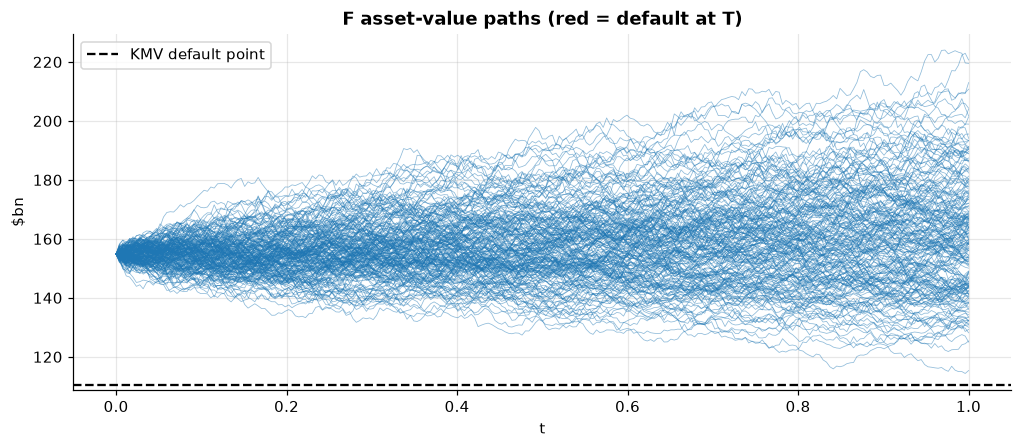

In [7]:
CREDIT_TICKER = "F"   # Ford — any listed company works
try:
    E, sE, Dkmv, st, lt = load_equity_for_merton(CREDIT_TICKER)
    src = "live"
except Exception as e:
    E, sE, Dkmv, st, lt = 48e9, 0.38, 110e9, 57e9, 106e9; src = f"fallback ({e})"
m = merton_structural(E, sE, Dkmv, 1.0, 0.04)
print(f"{CREDIT_TICKER} [{src}]  E=${E/1e9:.1f}bn  σ_E={sE:.1%}  ST debt ${st/1e9:.1f}bn  LT debt ${lt/1e9:.1f}bn  → default point ${Dkmv/1e9:.1f}bn")
print(f"  Implied assets V=${m['V']/1e9:.1f}bn   σ_V={m['sigma_V']:.1%}   DD={m['DD']:.2f}   PD(1y)={m['PD']:.2%}   spread={1e4*m['spread']:.0f} bp")
print("  Note: pure Merton famously under-predicts short-dated spreads (no jumps to default) — hence CDS-implied hazards below.")

sims = m["V"] * np.exp((0.04 - 0.5*m["sigma_V"]**2)*np.linspace(0, 1, 253) + m["sigma_V"]*np.sqrt(1/252)*np.cumsum(np.hstack([np.zeros((200, 1)), np.random.default_rng(2).standard_normal((200, 252))]), 1))
tt = np.linspace(0, 1, 253)
for p_ in sims: plt.plot(tt, p_/1e9, color=C[3] if p_[-1] < Dkmv else C[0], lw=0.5, alpha=0.5)
plt.axhline(Dkmv/1e9, color="k", ls="--", label="KMV default point")
plt.title(f"{CREDIT_TICKER} asset-value paths (red = default at T)"); plt.xlabel("t"); plt.ylabel("$bn"); plt.legend();

### B.2 Reduced-form credit: CDS and hazard rates

Default is the first jump of a Poisson process with intensity $\lambda(t)$, so survival is $Q(t)=\exp\!\big(-\int_0^t\lambda(s)\,ds\big)$. A CDS swaps a running premium $s$ for a payment $(1-R)$ at default:

$$
\underbrace{s\sum_{i}\tau_i\,P(0,t_i)\left[Q(t_i)+\tfrac12\big(Q(t_{i-1})-Q(t_i)\big)\right]}_{\text{premium leg}=s\,\cdot\,\text{RPV01}}
\;=\;
\underbrace{(1-R)\sum_i P(0,t_i)\big(Q(t_{i-1})-Q(t_i)\big)}_{\text{protection leg}}
$$

With piecewise-constant $\lambda$, we **bootstrap** tenor by tenor (1y, 3y, 5y, …), solving each par equation for one new hazard. The **credit triangle** is a handy check: $s\approx\lambda(1-R)$.

Investment grade         hazards (%): [0.58 0.92 1.54 2.14 2.44 2.72]   5y survival 92.9%
High yield               hazards (%): [4.17 5.91 7.22 8.66 8.28 7.89]   5y survival 70.7%
Distressed (inverted)    hazards (%): [25.01 15.51 11.55 10.07  9.58  8.73]   5y survival 48.6%


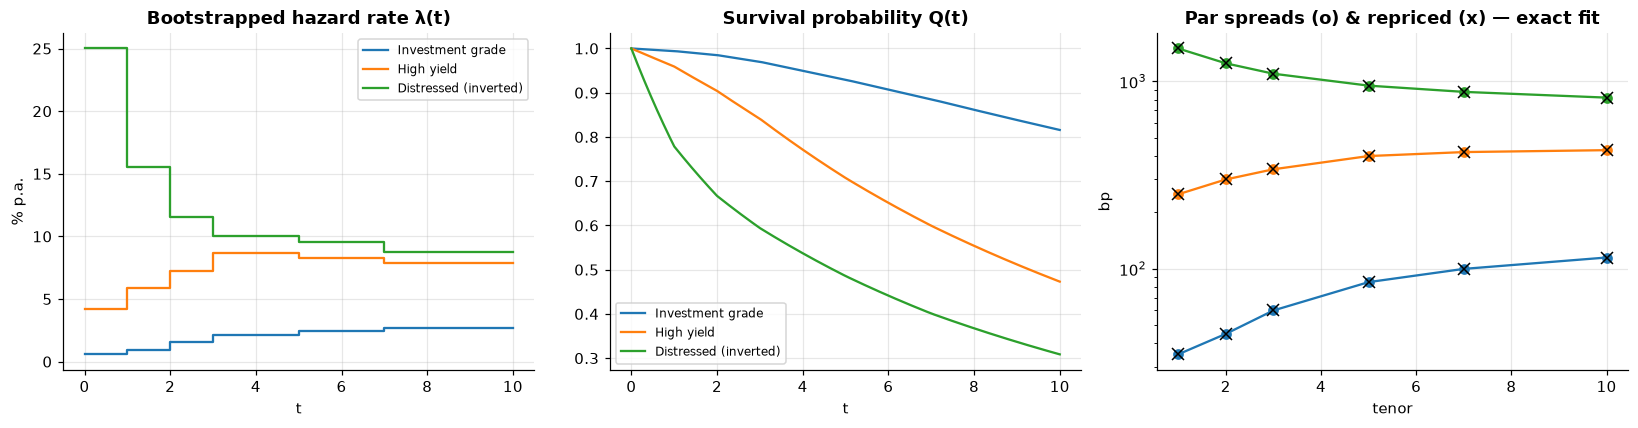

In [8]:
tenors = np.array([1, 2, 3, 5, 7, 10.])
curves = {"Investment grade": np.array([35, 45, 60, 85, 100, 115.]),
          "High yield":       np.array([250, 300, 340, 400, 420, 430.]),
          "Distressed (inverted)": np.array([1500, 1250, 1100, 950, 880, 820.])}
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, (nm, sp) in enumerate(curves.items()):
    hc = bootstrap_hazard(tenors, sp, 0.04, R=0.4)
    tg = np.linspace(0, 10, 400)
    ax[0].step(np.concatenate([[0], tenors]), 100*np.concatenate([[hc.h[0]], hc.h]), where="pre", color=C[i], label=nm)
    ax[1].plot(tg, hc.Q(tg), color=C[i], label=nm)
    ax[2].plot(tenors, sp, "o-", color=C[i], label=nm)
    ax[2].plot(tenors, [1e4*(lambda a_p: a_p[1]/a_p[0])(cds_legs(hc, T_, 0.04)) for T_ in tenors], "x", color="k", ms=8)
    print(f"{nm:24s} hazards (%): {np.round(100*hc.h, 2)}   5y survival {hc.Q(5)[0]:.1%}")
ax[0].set(title="Bootstrapped hazard rate λ(t)", xlabel="t", ylabel="% p.a."); ax[0].legend(fontsize=8)
ax[1].set(title="Survival probability Q(t)", xlabel="t"); ax[1].legend(fontsize=8)
ax[2].set(yscale="log", title="Par spreads (o) & repriced (x) — exact fit", xlabel="tenor", ylabel="bp")
plt.tight_layout()

## C · Portfolio construction

### C.1 Mean–variance (Markowitz 1952)

$$
\min_{w}\ w^\top\Sigma w\quad\text{s.t.}\quad w^\top\mu=\mu_p,\ \ \mathbf 1^\top w=1\ (,\ w\ge0),
\qquad
w_{\text{tan}}=\arg\max_w\frac{w^\top\mu-r_f}{\sqrt{w^\top\Sigma w}}\ \propto\ \Sigma^{-1}(\mu-r_f\mathbf 1)\ \text{(unconstrained)}.
$$

The sample covariance $S$ is noisy when $N$ assets ≈ $T$ observations, and the optimiser **maximises estimation error**. **Ledoit–Wolf** shrinks toward a structured target:

$$
\hat\Sigma = \delta^*\,\bar\mu I + (1-\delta^*)\,S,\qquad
\delta^* = \frac{\tfrac1{T^2}\sum_t\lVert x_tx_t^\top - S\rVert_F^2}{\lVert S-\bar\mu I\rVert_F^2}\wedge 1.
$$

### C.2 Black–Litterman (1992)

Start from **equilibrium** returns implied by market weights (reverse optimisation), then blend in views $P\mu = Q + \varepsilon,\ \varepsilon\sim\mathcal N(0,\Omega)$:

$$
\pi = \delta\,\Sigma\,w_{\text{mkt}},\qquad
\mu_{BL} = \left[(\tau\Sigma)^{-1} + P^\top\Omega^{-1}P\right]^{-1}\left[(\tau\Sigma)^{-1}\pi + P^\top\Omega^{-1}Q\right].
$$

### C.3 Risk parity (equal risk contribution)

The risk contribution of asset $i$ is $RC_i = w_i\,\frac{(\Sigma w)_i}{\sqrt{w^\top\Sigma w}}$, with $\sum_i RC_i=\sigma_p$ (Euler). ERC sets all $RC_i$ equal, solved via the convex problem

$$
y^* = \arg\min_{y>0}\ \tfrac12 y^\top\Sigma y - \tfrac1n\sum_i\ln y_i,\qquad w = y^*/\mathbf 1^\top y^*.
$$

Live monthly returns: 98 months × 11 sector ETFs (2018-08 → 2026-09)
Ledoit–Wolf shrinkage intensity δ* = 0.068


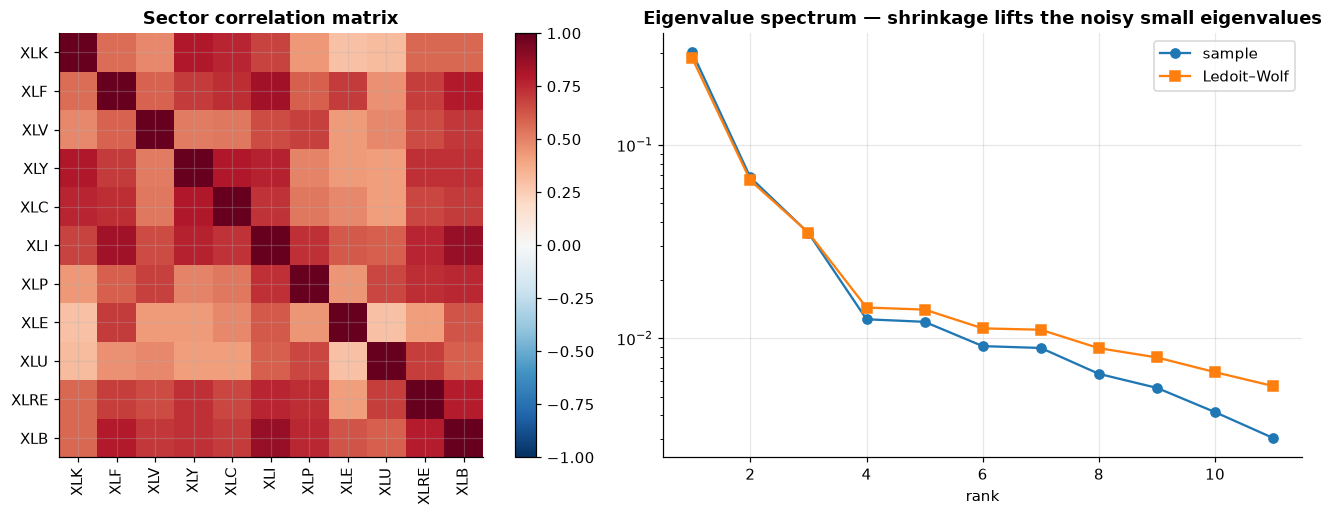

In [9]:
R, live_px = load_returns()
print(("Live" if live_px else "Synthetic") + f" monthly returns: {R.shape[0]} months × {R.shape[1]} sector ETFs ({R.index[0]:%Y-%m} → {R.index[-1]:%Y-%m})" if live_px else "Synthetic returns")
mu = R.mean().values * 12
S_sample = np.cov(R.values.T) * 12
S_lw, delta = ledoit_wolf(R.values); S_lw *= 12
print(f"Ledoit–Wolf shrinkage intensity δ* = {delta:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))
corr = np.corrcoef(R.values.T)
im = ax[0].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax[0].set(xticks=range(len(SECTORS)), yticks=range(len(SECTORS)), xticklabels=SECTORS, yticklabels=SECTORS, title="Sector correlation matrix")
ax[0].tick_params(axis="x", rotation=90); plt.colorbar(im, ax=ax[0], fraction=0.046)

ev_s, ev_l = np.linalg.eigvalsh(S_sample)[::-1], np.linalg.eigvalsh(S_lw)[::-1]
ax[1].semilogy(range(1, len(ev_s)+1), ev_s, "o-", label="sample"); ax[1].semilogy(range(1, len(ev_l)+1), ev_l, "s-", label="Ledoit–Wolf")
ax[1].set(title="Eigenvalue spectrum — shrinkage lifts the noisy small eigenvalues", xlabel="rank"); ax[1].legend()
plt.tight_layout()

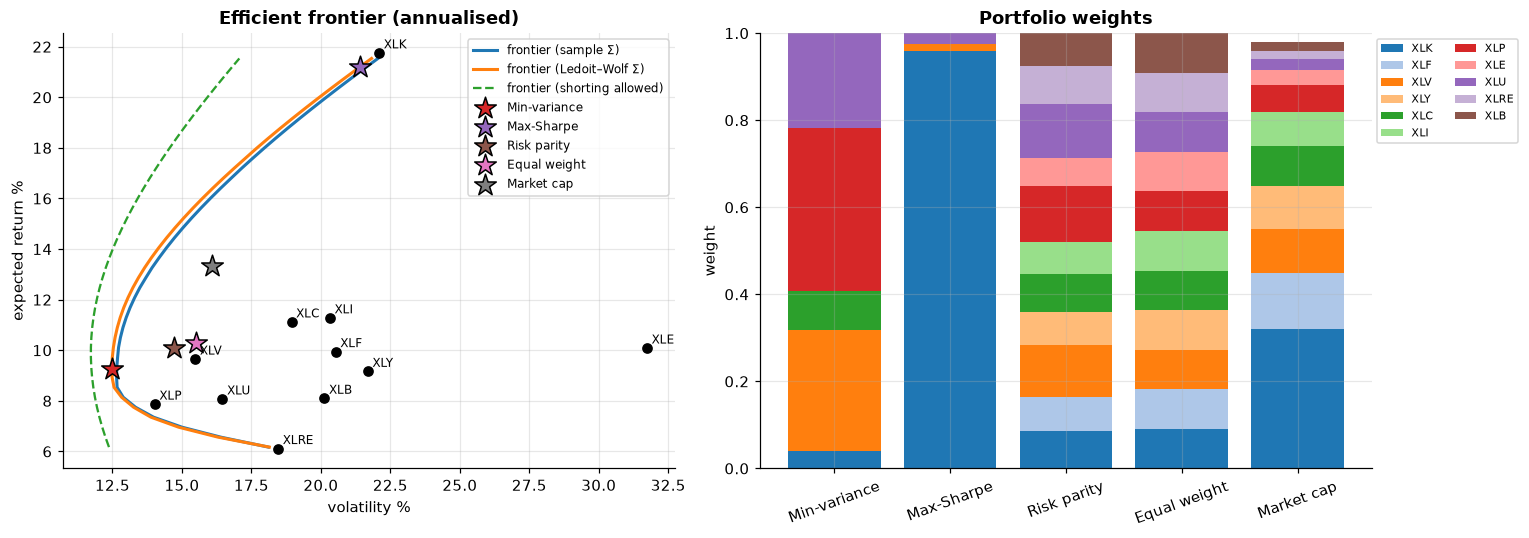

In [10]:
targets = np.linspace(mu.min()*1.01, mu.max()*0.99, 40)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for i, (lab, Sg) in enumerate([("sample Σ", S_sample), ("Ledoit–Wolf Σ", S_lw)]):
    W, vols = efficient_frontier(mu, Sg, targets)
    ax[0].plot(100*vols, 100*targets, color=C[i], lw=2, label=f"frontier ({lab})")
Wu, vu = efficient_frontier(mu, S_lw, targets, long_only=False)
ax[0].plot(100*vu, 100*targets, "--", color=C[2], label="frontier (shorting allowed)")
vol_i = np.sqrt(np.diag(S_lw))
ax[0].scatter(100*vol_i, 100*mu, color="k", zorder=3)
for t_, x_, y_ in zip(SECTORS, vol_i, mu): ax[0].annotate(t_, (100*x_, 100*y_), fontsize=8, xytext=(3, 3), textcoords="offset points")
ports = {"Min-variance": min_variance(S_lw), "Max-Sharpe": max_sharpe(mu, S_lw, 0.04), "Risk parity": risk_parity(S_lw),
         "Equal weight": np.full(len(mu), 1/len(mu)), "Market cap": MKT_W}
for i, (nm, w) in enumerate(ports.items()):
    ax[0].scatter(100*np.sqrt(w @ S_lw @ w), 100*w @ mu, marker="*", s=220, color=C[i+3], edgecolor="k", zorder=4, label=nm)
ax[0].set(title="Efficient frontier (annualised)", xlabel="volatility %", ylabel="expected return %"); ax[0].legend(fontsize=8)

bottom = np.zeros(len(ports))
for j, t_ in enumerate(SECTORS):
    vals = np.array([w[j] for w in ports.values()])
    ax[1].bar(list(ports.keys()), vals, bottom=bottom, color=cm.tab20(j), label=t_); bottom += vals
ax[1].set(title="Portfolio weights", ylabel="weight"); ax[1].legend(fontsize=7, ncol=2, bbox_to_anchor=(1, 1)); ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout()

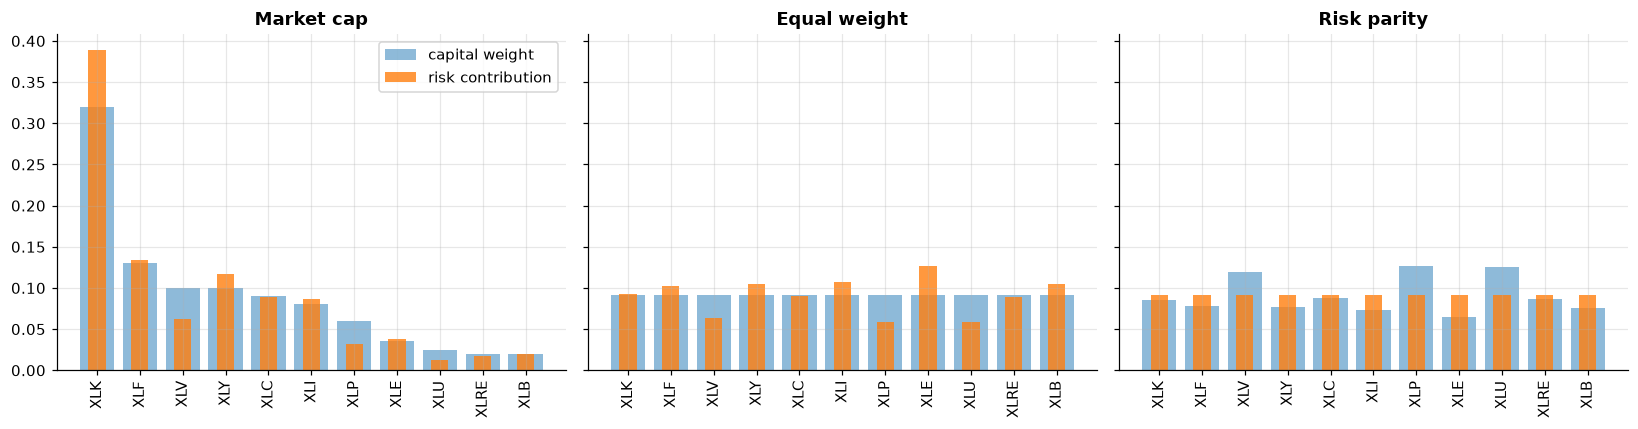

In [11]:
# Risk contributions — capital allocation ≠ risk allocation
fig, ax = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for a, nm in zip(ax, ["Market cap", "Equal weight", "Risk parity"]):
    w = ports[nm]
    a.bar(SECTORS, w, alpha=0.5, label="capital weight"); a.bar(SECTORS, risk_contrib(w, S_lw), alpha=0.8, width=0.4, label="risk contribution")
    a.set_title(nm); a.tick_params(axis="x", rotation=90)
ax[0].legend(); plt.tight_layout()

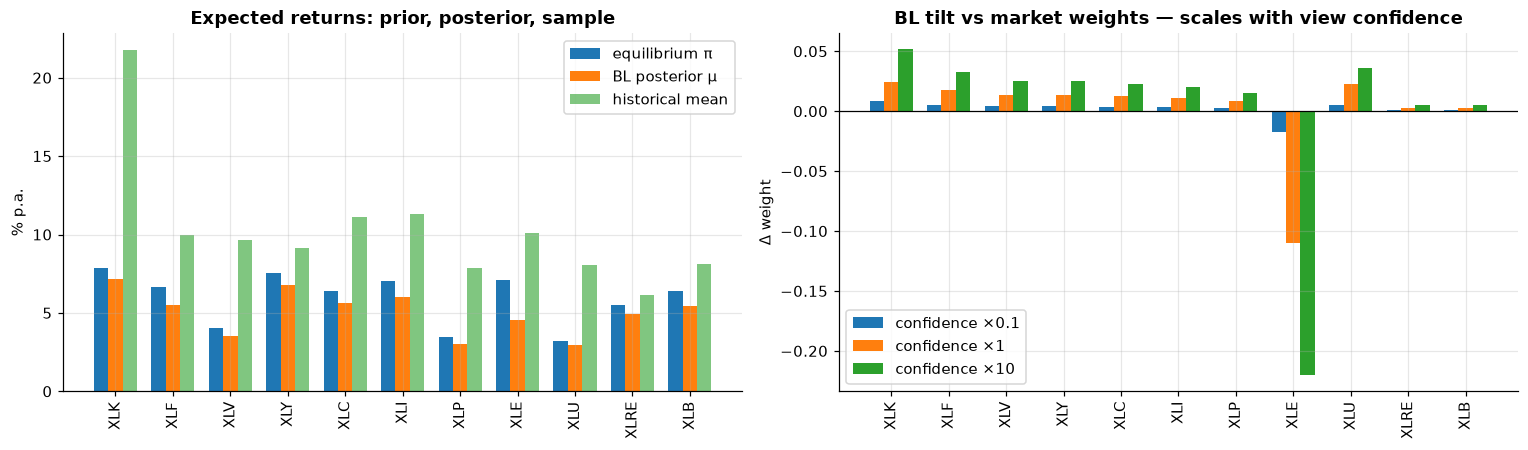

In [12]:
# Black–Litterman with two views
i_ = {t: k for k, t in enumerate(SECTORS)}
P = np.zeros((2, len(SECTORS)))
P[0, i_["XLK"]] = 1; P[0, i_["XLU"]] = -1          # view 1: Tech beats Utilities by 4 %/yr
P[1, i_["XLE"]] = 1                                 # view 2: Energy returns 2 %/yr absolute
Q = np.array([0.04, 0.02])
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
pi, mu_bl, w_bl = black_litterman(S_lw, MKT_W, P, Q, conf=[1, 1])
x = np.arange(len(SECTORS))
ax[0].bar(x-0.25, 100*pi, 0.25, label="equilibrium π"); ax[0].bar(x, 100*mu_bl, 0.25, label="BL posterior μ")
ax[0].bar(x+0.25, 100*mu, 0.25, label="historical mean", alpha=0.6)
ax[0].set(xticks=x, xticklabels=SECTORS, title="Expected returns: prior, posterior, sample", ylabel="% p.a."); ax[0].legend(); ax[0].tick_params(axis="x", rotation=90)
for j, c_ in enumerate([0.1, 1, 10]):
    _, _, w_c = black_litterman(S_lw, MKT_W, P, Q, conf=[c_, c_])
    ax[1].bar(x + (j-1)*0.25, w_c - MKT_W, 0.25, label=f"confidence ×{c_}")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set(xticks=x, xticklabels=SECTORS, title="BL tilt vs market weights — scales with view confidence", ylabel="Δ weight"); ax[1].legend(); ax[1].tick_params(axis="x", rotation=90)
plt.tight_layout()

### C.4 Walk-forward backtest

Each month, estimate $\hat\Sigma$ (Ledoit–Wolf) and $\hat\mu$ on the trailing 36 months **only**, rebalance, and record the next month's return — no look-ahead. Metrics: annualised return, volatility, Sharpe $=\frac{\bar r}{\hat\sigma}\sqrt{12}$, and maximum drawdown $\max_t\big(\max_{s\le t}W_s - W_t\big)$.

strategy                  ann.ret  ann.vol  Sharpe   maxDD
Equal weight                9.56%   14.22%    0.67  -18.3%
Min-variance                7.27%   12.59%    0.58  -16.8%
Risk parity                 8.94%   13.87%    0.64  -19.1%
Max-Sharpe (sample μ)       2.42%   14.59%    0.17  -27.0%


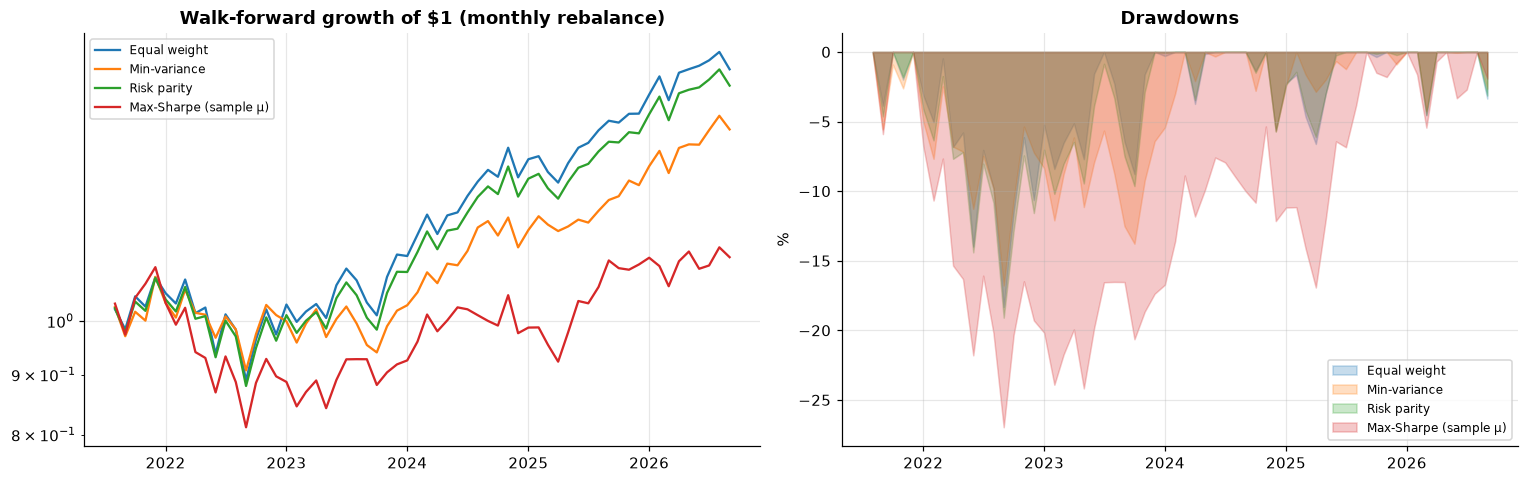

In [13]:
lb = 36 if len(R) > 60 else 24
strats = {"Equal weight": lambda win, Sg: np.full(Sg.shape[0], 1/Sg.shape[0]),
          "Min-variance": lambda win, Sg: min_variance(Sg),
          "Risk parity": lambda win, Sg: risk_parity(Sg),
          "Max-Sharpe (sample μ)": lambda win, Sg: max_sharpe(win.mean(0), Sg)}
bt = walk_forward(R, lookback=lb, strategies=strats)
dates = R.index[lb:]
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
print(f"{'strategy':24s} {'ann.ret':>8s} {'ann.vol':>8s} {'Sharpe':>7s} {'maxDD':>7s}")
for i, (nm, rr) in enumerate(bt.items()):
    eq = np.cumsum(rr)
    ax[0].plot(dates, np.exp(eq), color=C[i], label=nm)
    dd = np.exp(eq - np.maximum.accumulate(eq)) - 1
    ax[1].fill_between(dates, 100*dd, 0, color=C[i], alpha=0.25, label=nm)
    print(f"{nm:24s} {12*rr.mean():8.2%} {np.sqrt(12)*rr.std():8.2%} {np.sqrt(12)*rr.mean()/rr.std():7.2f} {dd.min():7.1%}")
ax[0].set(title="Walk-forward growth of $1 (monthly rebalance)", yscale="log"); ax[0].legend(fontsize=8)
ax[1].set(title="Drawdowns", ylabel="%"); ax[1].legend(fontsize=8)
plt.tight_layout()

### Takeaways

* **Early exercise:** LSM brackets the true American price from both sides and scales to high-dimensional problems where trees can't go.
* **Credit:** structural models tie credit to equity (and explain *why* spreads widen when equity falls), but under-price short-dated risk; reduced-form hazards fit CDS markets exactly.
* **Portfolios:** estimated means are the weak link — unconstrained max-Sharpe usually loses out of sample. Shrinkage, Black–Litterman priors and risk parity are all ways of **not trusting $\hat\mu$**.